# CytoTable with Iceberg profiles and images

This notebook shows how CytoTable can:

- write a materialized `profiles.joined_profiles` table
- write cropped images to `images.image_crops`
- optionally write whole source images to `images.source_images`
- read both Iceberg and single-Parquet outputs through the same
  `cytotable.read_table` and `cytotable.list_tables` API

The example uses the local `ExampleHuman` CellProfiler dataset bundled with the
repository test data.

In [1]:
import pathlib
import shutil

import cytotable
from ome_arrow import OMEArrow

# paths used throughout the notebook
source_path = "../../../tests/data/cellprofiler/ExampleHuman"
warehouse_path = pathlib.Path("./examplehuman_iceberg_warehouse")
parquet_path = pathlib.Path("./examplehuman.parquet")

Remove prior outputs so the example can be rerun cleanly.

In [2]:
if warehouse_path.exists():
    shutil.rmtree(warehouse_path)
if parquet_path.exists():
    parquet_path.unlink()

Show the available CellProfiler source files.

In [3]:
sorted(path.name for path in pathlib.Path(source_path).glob("*"))

['AS_09125_050116030001_D03f00d0.tif',
 'AS_09125_050116030001_D03f00d0_Overlay.png',
 'AS_09125_050116030001_D03f00d1.tif',
 'AS_09125_050116030001_D03f00d2.tif',
 'Cells.csv',
 'Cytoplasm.csv',
 'ExampleHuman.cppipe',
 'Experiment.csv',
 'Image.csv',
 'Nuclei.csv',
 'PH3.csv']

## Build an Iceberg warehouse with joined profiles, image crops, and source images

In [4]:
%%time

iceberg_result = cytotable.convert(
    source_path=source_path,
    source_datatype="csv",
    dest_path=str(warehouse_path),
    dest_backend="iceberg",
    dest_datatype="parquet",
    preset="cellprofiler_csv",
    image_dir=source_path,
    include_source_images=True,
)
print(iceberg_result)

/Users/buntend/Documents/work/CytoTable/docs/source/examples/examplehuman_iceberg_warehouse
CPU times: user 1min 2s, sys: 2.8 s, total: 1min 5s
Wall time: 1min 24s


List the tables and views in the warehouse using the top-level CytoTable API.

In [5]:
cytotable.list_tables(warehouse_path)

['images.image_crops',
 'images.source_images',
 'profiles.joined_profiles',
 'profiles.profile_with_images']

Read the joined measurement table.

In [6]:
joined_profiles = cytotable.read_table(warehouse_path, "joined_profiles")
joined_profiles[["Metadata_ObjectID"]].head()

,Metadata_ObjectID
0,obj-f5800564-ea8c-570e-b804-7f057a18de43
1,obj-5f8d57f7-f250-5172-be79-d246cf5567bc
2,obj-44e0b10d-2a93-5d30-acb2-d5d6f5d9ae45
3,obj-ab5e94f3-f3fa-5168-809a-3689b75bbfd3
4,obj-3f001126-0d7c-5728-b792-835da9abb98c


Read the object-level image crop table.

In [7]:
image_crops = cytotable.read_table(warehouse_path, "image_crops")
image_crops[
    [
        "Metadata_ObjectID",
        "Metadata_ImageCropID",
        "source_image_file",
        "ome_arrow_image",
    ]
].head()

,Metadata_ObjectID,Metadata_ImageCropID,source_image_file,ome_arrow_image
0,obj-f5800564-ea8c-570e-b804-7f057a18de43,obj-775aedfc-97c5-59f6-a22e-bbb089c310b3,AS_09125_050116030001_D03f00d0.tif,"{'type': 'ome.arrow', 'version': '0.0.8', 'id'..."
1,obj-f5800564-ea8c-570e-b804-7f057a18de43,obj-de8f365c-1639-530d-92ad-69a2b2d4838c,AS_09125_050116030001_D03f00d1.tif,"{'type': 'ome.arrow', 'version': '0.0.8', 'id'..."
2,obj-f5800564-ea8c-570e-b804-7f057a18de43,obj-a9019963-9396-5447-b70c-983e33157212,AS_09125_050116030001_D03f00d2.tif,"{'type': 'ome.arrow', 'version': '0.0.8', 'id'..."
3,obj-5f8d57f7-f250-5172-be79-d246cf5567bc,obj-431b50d8-4f13-5d43-9afc-1efa34c86a24,AS_09125_050116030001_D03f00d0.tif,"{'type': 'ome.arrow', 'version': '0.0.8', 'id'..."
4,obj-5f8d57f7-f250-5172-be79-d246cf5567bc,obj-997d7b1b-bc08-57ff-b084-40de999c9a76,AS_09125_050116030001_D03f00d1.tif,"{'type': 'ome.arrow', 'version': '0.0.8', 'id'..."


Read the full source image table.

In [8]:
source_images = cytotable.read_table(warehouse_path, "source_images")
source_images[
    [
        "Metadata_ImageID",
        "source_image_file",
        "ome_arrow_image",
    ]
].head()

,Metadata_ImageID,source_image_file,ome_arrow_image
0,obj-d2b0bf00-10ce-5068-80ff-0307738ff67c,AS_09125_050116030001_D03f00d0.tif,"{'type': 'ome.arrow', 'version': '0.0.8', 'id'..."
1,obj-a6df374f-a801-5291-a756-730a6d192529,AS_09125_050116030001_D03f00d1.tif,"{'type': 'ome.arrow', 'version': '0.0.8', 'id'..."
2,obj-a68bb17e-cfde-5f67-9268-c26c9f89ad97,AS_09125_050116030001_D03f00d2.tif,"{'type': 'ome.arrow', 'version': '0.0.8', 'id'..."


Read the profile-centric manifest view that joins profile rows to image crop
references.

In [9]:
profile_with_images = cytotable.read_table(warehouse_path, "profile_with_images")
profile_with_images[["Metadata_ObjectID", "source_image_file"]].head()

,Metadata_ObjectID,source_image_file
0,obj-f5800564-ea8c-570e-b804-7f057a18de43,AS_09125_050116030001_D03f00d0.tif
1,obj-f5800564-ea8c-570e-b804-7f057a18de43,AS_09125_050116030001_D03f00d1.tif
2,obj-f5800564-ea8c-570e-b804-7f057a18de43,AS_09125_050116030001_D03f00d2.tif
3,obj-5f8d57f7-f250-5172-be79-d246cf5567bc,AS_09125_050116030001_D03f00d0.tif
4,obj-5f8d57f7-f250-5172-be79-d246cf5567bc,AS_09125_050116030001_D03f00d1.tif


## Show a cropped image next to profile values

The image tables store `OME-Arrow` objects rather than plain NumPy arrays, so
this helper searches the nested object for the first array-like image payload
and reshapes it into something Matplotlib can display.

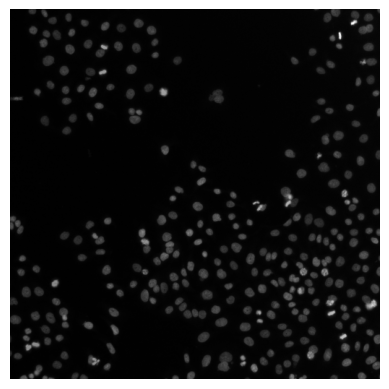

In [10]:
# use ome_arrow to display a whole image (from the source_images table)
OMEArrow(source_images["ome_arrow_image"].iloc[0])

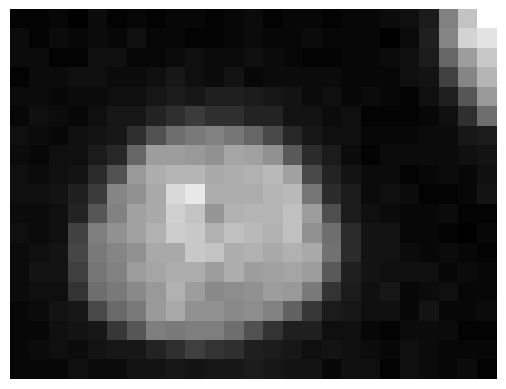

In [11]:
# use ome_arrow to display a cropped image (from the image_crops table)
OMEArrow(image_crops["ome_arrow_image"].iloc[3])